# Weather Forecasting Pipeline — 3-Hour Average Targets
Predicts the **average** of the 3 hours centred on the forecast horizon
(i.e. `horizon-1`, `horizon`, `horizon+1` hours ahead) instead of a single
point-in-time value. Everything else — lag/rolling features, train/val/test
split, XGBoost, evaluation — is unchanged.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import joblib

In [2]:
# CONFIG
FORECAST_HORIZON = 24  # centre of the 3-hour prediction window
# Targets = mean of hours (FORECAST_HORIZON-1, FORECAST_HORIZON, FORECAST_HORIZON+1)

BASE_TARGET_COLS = [
    "temperature_2m",
    "apparent_temperature",
    "precipitation",
    "wind_speed_10m",
    "wind_direction_10m",
    "relative_humidity_2m",
]

In [3]:
df = pd.read_csv('/home/makos/dev/weather_dag/raw_data/city_data_2026-05-22_17-12-01.csv', index_col=0)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df.head()

,date,temperature_2m,weather_code,apparent_temperature,precipitation,relative_humidity_2m,dew_point_2m,surface_pressure,wind_speed_10m,wind_direction_10m
0,2024-04-14 00:00:00+00:00,11.7595,3.0,10.717299,0.0,78.057710,8.0595,910.40910,3.671294,101.309900
1,2024-04-14 01:00:00+00:00,12.2095,3.0,10.925562,0.0,75.521110,8.0095,910.28894,5.241679,105.945465
2,2024-04-14 02:00:00+00:00,12.0595,3.0,10.888635,0.0,76.011246,7.9595,910.41900,4.379589,99.462250
3,2024-04-14 03:00:00+00:00,11.7095,3.0,10.643064,0.0,76.733795,7.7595,910.21250,3.319036,49.398785
4,2024-04-14 04:00:00+00:00,10.1595,3.0,8.813246,0.0,82.200250,7.2595,909.69336,4.394360,34.992100


In [4]:
def engineer_features(df: pd.DataFrame, target_cols, horizon: int = 24) -> pd.DataFrame:
    """
    Build features and 3-hour-average targets.

    For each target column the label is:
        mean( value[t + horizon - 1],
              value[t + horizon    ],
              value[t + horizon + 1] )

    This smooths out single-hour spikes and gives the model a more
    stable learning signal while still representing the forecast window.

    Parameters
    ----------
    df         : raw DataFrame with a 'date' column and hourly rows
    target_cols: base column names to forecast
    horizon    : centre of the 3-hour prediction window (hours ahead)
    """
    df = df.copy().sort_values('date').reset_index(drop=True)

    # ── Time features ────────────────────────────────────────────────────────
    df['hour']        = df['date'].dt.hour
    df['day_of_week'] = df['date'].dt.dayofweek
    df['day_of_year'] = df['date'].dt.dayofyear
    df['month']       = df['date'].dt.month

    # ── Lag / rolling features (leakage-safe: only past values) ──────────────
    for col in target_cols:
        for lag in [1, 3, 6, 12, 24]:
            df[f'{col}_lag_{lag}'] = df[col].shift(lag)

        df[f'{col}_roll_mean_6'] = df[col].shift(1).rolling(6).mean()
        df[f'{col}_roll_std_6']  = df[col].shift(1).rolling(6).std()

    # ── 3-hour-average targets ────────────────────────────────────────────────
    # Average the three hours centred on `horizon`:
    #   shift(-(horizon-1))  →  value at t + (horizon-1)  [one hour early]
    #   shift(-horizon)      →  value at t + horizon       [exact horizon]
    #   shift(-(horizon+1))  →  value at t + (horizon+1)  [one hour late]
    for col in target_cols:
        df[f'target_{col}'] = (
            df[col].shift(-(horizon - 1)) +
            df[col].shift(-horizon)       +
            df[col].shift(-(horizon + 1))
        ) / 3

    df = df.dropna().reset_index(drop=True)
    return df

In [5]:
df.shape

(17544, 10)

In [6]:
df_processed = engineer_features(df, BASE_TARGET_COLS, FORECAST_HORIZON)
TARGET_COLS  = [f'target_{c}' for c in BASE_TARGET_COLS]
df_processed.head()

,date,temperature_2m,weather_code,apparent_temperature,precipitation,relative_humidity_2m,dew_point_2m,surface_pressure,wind_speed_10m,wind_direction_10m,...,relative_humidity_2m_lag_12,relative_humidity_2m_lag_24,relative_humidity_2m_roll_mean_6,relative_humidity_2m_roll_std_6,target_temperature_2m,target_apparent_temperature,target_precipitation,target_wind_speed_10m,target_wind_direction_10m,target_relative_humidity_2m
0,2024-04-15 00:00:00+00:00,13.5595,3.0,12.377680,0.0,66.596870,7.4595,913.88727,3.600000,126.869990,...,66.999954,78.057710,59.124727,8.715395,14.092833,13.056237,0.000000,4.474078,196.320487,69.169915
1,2024-04-15 01:00:00+00:00,14.0095,3.0,12.887894,0.0,62.290268,6.9095,913.67535,2.276840,71.564964,...,59.114796,75.521110,62.101221,7.410539,13.476167,12.229090,0.000000,4.965149,197.126993,69.438115
2,2024-04-15 02:00:00+00:00,13.5095,3.0,12.387577,0.0,63.687744,6.7595,913.51074,2.036468,135.000100,...,54.010616,76.011246,64.266169,4.065406,13.226167,11.892435,0.066667,5.295254,197.953280,69.860947
3,2024-04-15 03:00:00+00:00,13.4095,3.0,11.921997,0.0,61.723427,6.2095,913.38730,3.671294,168.690110,...,50.977245,76.733795,65.277889,2.554407,12.942833,11.660683,0.166667,5.412392,215.363370,72.553327
4,2024-04-15 04:00:00+00:00,8.5595,3.0,6.730034,0.0,74.637054,4.3095,911.39960,3.219938,153.435010,...,49.401703,82.200250,64.331933,2.660466,12.359500,11.233573,0.333333,5.547057,223.189180,79.166098


In [7]:
def build_datasets(df: pd.DataFrame, target_cols):
    feature_cols = [
        c for c in df.columns
        if c not in target_cols + ['date'] + BASE_TARGET_COLS
    ]

    n         = len(df)
    train_end = int(n * 0.70)
    val_end   = int(n * 0.85)

    train_df = df.iloc[:train_end]
    val_df   = df.iloc[train_end:val_end]
    test_df  = df.iloc[val_end:]

    return (
        train_df[feature_cols], train_df[target_cols],
        val_df[feature_cols],   val_df[target_cols],
        test_df[feature_cols],  test_df[target_cols],
        feature_cols
    )

In [8]:
X_train, y_train, X_val, y_val, X_test, y_test, feature_cols = build_datasets(
    df_processed, TARGET_COLS
)

In [9]:
def train_model(X_train, y_train):
    base_model = XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42
    )

    model = MultiOutputRegressor(base_model)
    model.fit(X_train, y_train)
    return model

In [10]:
model = train_model(X_train, y_train)

In [11]:
def evaluate_model_detailed(model, X_test, y_test, target_cols, n_plot=200):
    """
    Evaluate and plot predictions against 3-hour-average actuals.
    Labels on the y-axis are the smoothed averages, so residuals are
    expected to be tighter than single-hour evaluation.
    """
    preds    = model.predict(X_test)
    preds_df = pd.DataFrame(preds, columns=target_cols, index=y_test.index)

    metrics = {}

    for col in target_cols:
        y_true = y_test[col]
        y_pred = preds_df[col]

        mae  = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2   = r2_score(y_true, y_pred)

        metrics[col] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}

        fig, axes = plt.subplots(1, 3, figsize=(20, 5))

        axes[0].plot(y_true.iloc[:n_plot].values, label='Actual (3h avg)')
        axes[0].plot(y_pred.iloc[:n_plot].values, label='Predicted')
        axes[0].set_title(f'{col}: Actual vs Predicted (3h avg)')
        axes[0].legend()

        axes[1].scatter(y_true, y_pred, alpha=0.4)
        min_val = min(y_true.min(), y_pred.min())
        max_val = max(y_true.max(), y_pred.max())
        axes[1].plot([min_val, max_val], [min_val, max_val], '--')
        axes[1].set_title(f'{col}: Scatter')

        residuals = y_true - y_pred
        axes[2].hist(residuals, bins=40)
        axes[2].set_title(f'{col}: Residuals')

        plt.tight_layout()
        plt.show()

    return pd.DataFrame(metrics).T

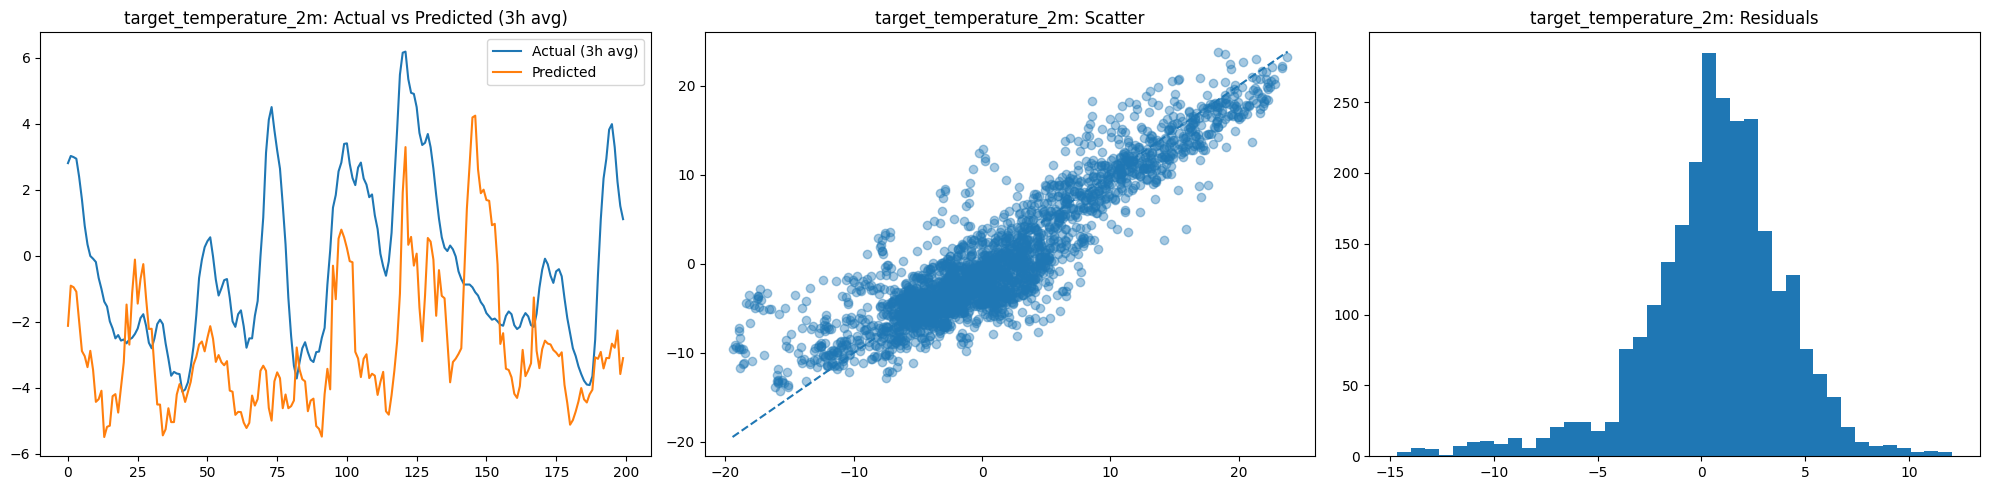

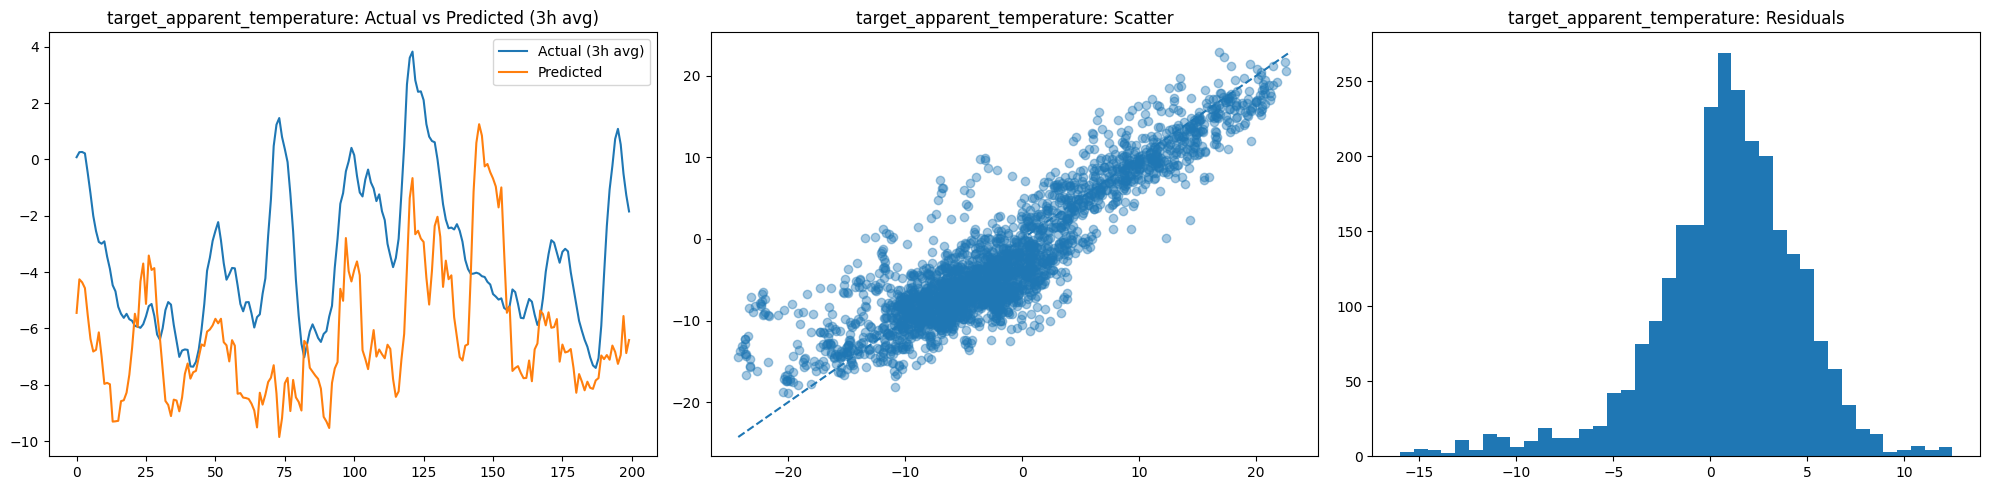

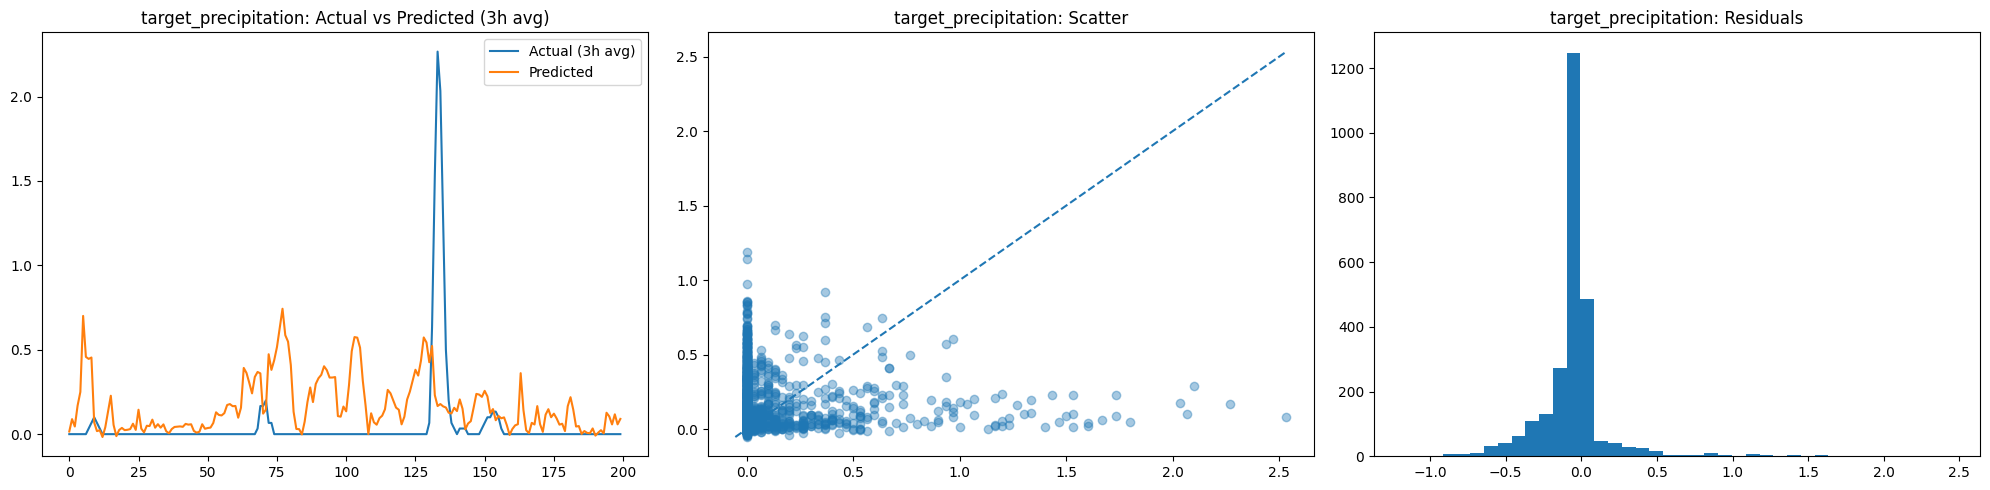

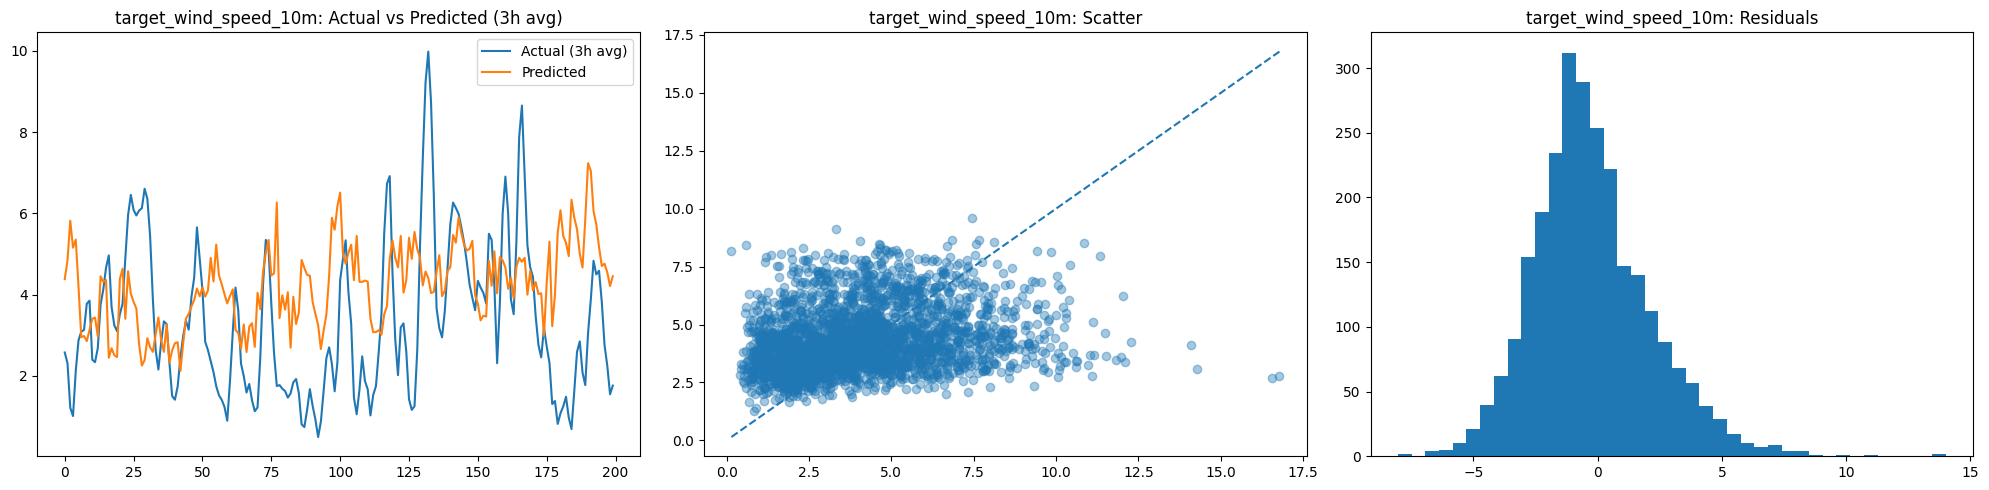

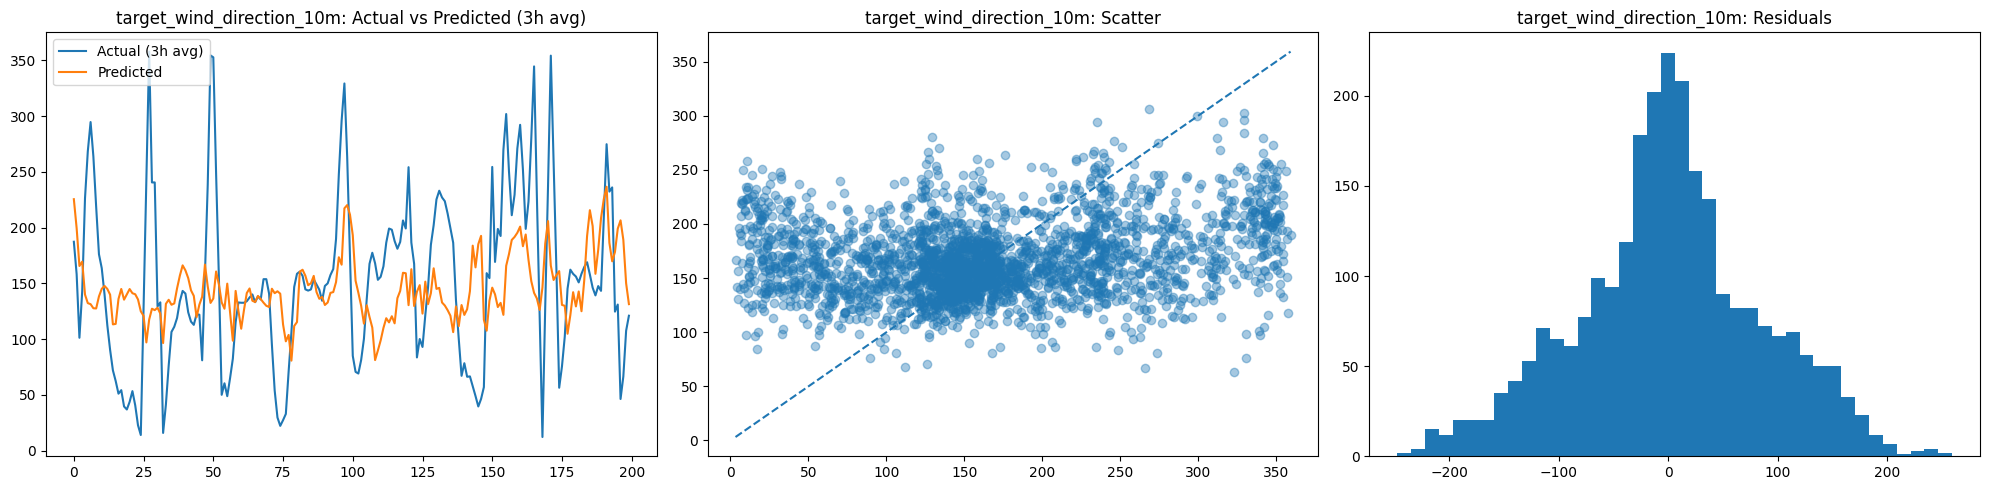

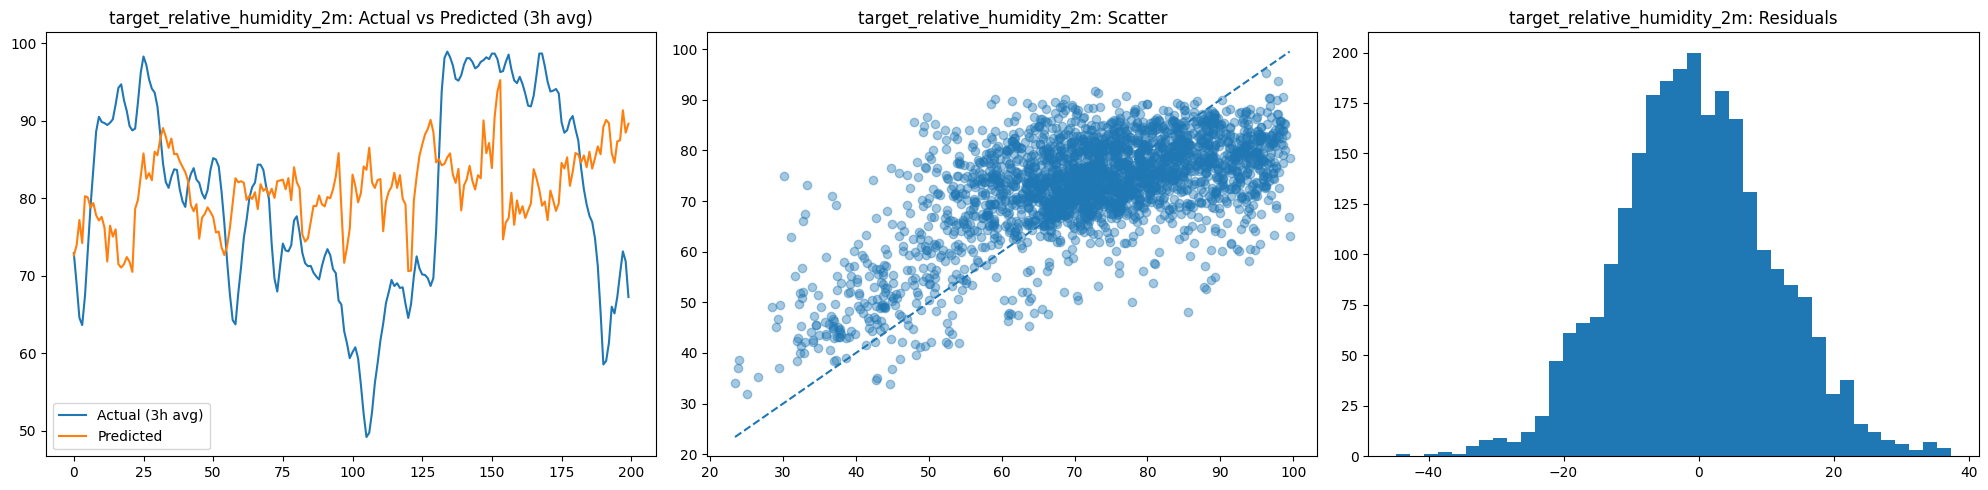

,MAE,RMSE,R2
target_temperature_2m,2.673148,3.578316,0.800956
target_apparent_temperature,2.982758,3.960002,0.797997
target_precipitation,0.133388,0.255897,-0.459038
target_wind_speed_10m,1.854989,2.387240,-0.114821
target_wind_direction_10m,64.994770,84.547015,0.010138
target_relative_humidity_2m,9.172817,11.613796,0.378419


In [12]:
metrics_df = evaluate_model_detailed(model, X_test, y_test, TARGET_COLS)
metrics_df

In [13]:
joblib.dump(model, 'weather_forecaster_3h_avg.pkl')

['weather_forecaster_3h_avg.pkl']